# Transformer Language Model


A causal Transformer language model built from Keras layers and trained on the same Shakespeare corpus as the KenLM notebook in this folder, so the two are directly comparable. Covers dataset windowing, multi-head self-attention with a causal mask, training, perplexity, and temperature-controlled sampling.

Coursework for ICS472 (Natural Language Processing), KFUPM. Run on Google Colab with a T4 GPU.


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.6)
import requests
import nltk
from nltk.corpus import treebank, brown, conll2000
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, MultiHeadAttention, LayerNormalization, Add, Dense, Dropout
from tensorflow.keras.callbacks import Callback, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow as tf

In [43]:
# Load text file
text = open('text.txt', 'r').read()

# Preview text
print(text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [44]:
# Split text into lines
lines = text.split('\n')

# Define split ratios
train_ratio = 0.7
val_ratio = 0.1
test_ratio = 0.2

# Calculate split indices based on the number of lines
total_lines = len(lines)
train_end = int(total_lines * train_ratio)
val_end = train_end + int(total_lines * val_ratio)

In [45]:
# Split the lines into train, validation, and test sets
train_lines = lines[:train_end]
val_lines = lines[train_end:val_end]
test_lines = lines[val_end:]

# Join the lines back into text
train_text = '\n'.join(train_lines)
val_text = '\n'.join(val_lines)
test_text = '\n'.join(test_lines)

In [46]:
# Check splits
print(f"Train length: {len(train_text)}")
print(f"Validation length: {len(val_text)}")
print(f"Test length: {len(test_text)}")

Train length: 799487
Validation length: 107679
Test length: 208225


In [47]:
# Preview the first 300 characters of each split
print("\nTrain Text Preview:\n", train_text[:300])
print("\nValidation Text Preview:\n", val_text[:300])
print("\nTest Text Preview:\n", test_text[:300])


Train Text Preview:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us

Validation Text Preview:
 
FLORIZEL:
He neither does nor shall.

POLIXENES:
Methinks a father
Is at the nuptial of his son a guest
That best becomes the table. Pray you once more,
Is not your father grown incapable
Of reasonable affairs? is he not stupid
With age and altering rheums? can he speak? hear?
Know man from man? di

Test Text Preview:
 Nay, if there be no remedy for it, but that you will
needs buy and sell men and women like beasts, we
shall have all the world drink brown and white bastard.

DUKE VINCENTIO:
O heavens! what stuff is here

POMPEY:
'Twas never merry world since, of two usuries, the
merriest was put down, and the wors


In [48]:
# Tokenize individual letters
tokenizer = Tokenizer()

# Fit tokenizer
tokenizer.fit_on_texts([train_text])

# Print vocabulary size
print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 10569


In [49]:
# Vectorize each split using the trained tokenizer
train_ids = tokenizer.texts_to_sequences([train_text])[0]
val_ids = tokenizer.texts_to_sequences([val_text])[0]
test_ids = tokenizer.texts_to_sequences([test_text])[0]

In [50]:
# Print lengths of tokenized sequences
print("\nTokenized sequence lengths:")
print("Train tokens:", len(train_ids))
print("Validation tokens:", len(val_ids))
print("Test tokens:", len(test_ids))


Tokenized sequence lengths:
Train tokens: 146139
Validation tokens: 18617
Test tokens: 34440


## Preparing the training targets

A language model predicts the next token, so the target sequence is the input shifted one position. Sequences are windowed at 20 timesteps with a stride of 10, batched in 32s.


In [51]:
# Function to prepare dataset for word-based sequences
def prepare_dataset(ids, input_timesteps=20, shift=10, batch_size=32):
    # Target word is the next word
    window_size = input_timesteps + 1

    slices = tf.data.Dataset.from_tensor_slices(ids)
    windows = slices.window(window_size, shift=shift, drop_remainder=True)
    dataset = windows.flat_map(lambda window: window.batch(window_size))
    batches = dataset.shuffle(10000).batch(batch_size)
    return batches

In [52]:
# Prepare datasets
train_batches = prepare_dataset(train_ids)
val_batches = prepare_dataset(val_ids)
test_batches = prepare_dataset(test_ids)

In [53]:
# Function to split features and labels
def split_features_labels(batches):
    return batches.map(lambda batch: (batch[:, :-1], batch[:, 1:]))

In [54]:
# Split for each dataset
train_Xy = split_features_labels(train_batches)
val_Xy = split_features_labels(val_batches)
test_Xy = split_features_labels(test_batches)

In [56]:
# Print an example from the training set
print("Train set example:")
for b in train_Xy.take(1):
    print("X1 length: ", len(b[0][0].numpy()))
    print("X1: ", b[0][0].numpy())
    print("\ny1 length: ", len(b[1][0].numpy()))
    print("y1: ", b[1][0].numpy())

Train set example:
X1 length:  20
X1:  [  46 4066   39   54    1  611    5  612    1   75  531   89   24 5683
 1359  138  170  170  577  432]

y1 length:  20
y1:  [4066   39   54    1  611    5  612    1   75  531   89   24 5683 1359
  138  170  170  577  432    1]


In [57]:
# Function to one-hot encode inputs and prefetch
def prepare_batches(Xy_batches, num_tokens):
    # One-hot encode the inputs
    Xy_batches = Xy_batches.map(
        lambda inputs, labels: (tf.one_hot(tf.cast(inputs, tf.int32), depth=num_tokens), labels)
    )
    # Prefetch data for performance
    Xy_batches = Xy_batches.prefetch(tf.data.AUTOTUNE)
    return Xy_batches

In [58]:
# Define the number of tokens
num_tokens = len(tokenizer.word_index) + 1

# Prepare train, validation, and test batches
train_Xy = prepare_batches(train_Xy, num_tokens)
val_Xy = prepare_batches(val_Xy, num_tokens)
test_Xy = prepare_batches(test_Xy, num_tokens)

In [59]:
# Print an example batch from the train set
print("Example batch from train set:")
for inputs, labels in train_Xy.take(1):
    print("Inputs shape:", inputs.shape)  # Should be (batch_size, sequence_length, num_tokens)
    print("Labels shape:", labels.shape)  # Should be (batch_size, sequence_length)

Example batch from train set:
Inputs shape: (32, 20, 10570)
Labels shape: (32, 20)


## Building the Transformer

Multi-head self-attention with a **causal mask**, so each position can attend to earlier positions and itself but never to the future. Without that mask the model could read the answer from its input and the task would be trivial.

Each block pairs attention with a feed-forward network, both wrapped in residual connections and layer normalization.


In [81]:
def transformer_block(inputs, embed_dim, num_heads, ff_dim, rate=0.1):
    # Multi-head attention

    # causal mask
    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads
    )(inputs, inputs, use_causal_mask=True)

    attention_output = Dropout(rate)(attention_output)
    out1 = LayerNormalization(epsilon=1e-6)(Add()([inputs, attention_output]))

    # FF network
    ffn_output = Dense(ff_dim, activation="relu")(out1)
    ffn_output = Dense(embed_dim)(ffn_output)
    ffn_output = Dropout(rate)(ffn_output)

    return LayerNormalization(epsilon=1e-6)(Add()([out1, ffn_output]))

def build_transformer_model(num_tokens, input_timesteps=20, embed_dim=128, num_heads=4, ff_dim=256):
    inputs = Input(shape=(input_timesteps, num_tokens))

    # Proj to embedding dimension
    x = Dense(embed_dim)(inputs)

    # Pos Encoding
    positions = tf.range(start=0, limit=input_timesteps, delta=1)
    pos_encoding = tf.keras.layers.Embedding(
        input_dim=input_timesteps,
        output_dim=embed_dim
    )(positions)
    x = x + pos_encoding

    # layers & output layer
    x = transformer_block(x, embed_dim, num_heads, ff_dim)
    x = transformer_block(x, embed_dim, num_heads, ff_dim)
    outputs = Dense(num_tokens, activation="softmax")(x)

    return Model(inputs=inputs, outputs=outputs)

In [82]:
model = build_transformer_model(num_tokens)

## Compiling and training

Adam at a learning rate of 1e-4, trained for 10 epochs against the validation split.


In [84]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [85]:
# Print the model summary
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 20, 10570) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 20, 128)   │  1,353,088 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 20, 128)   │          0 │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 128)   │     66,048 │ add_25[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_25[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 20, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_26 (Add)        │ (None, 20, 128)   │          0 │ add_25[0][0],     │
│                     │                   │            │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 128)   │        256 │ add_26[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 20, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 20, 128)   │     32,896 │ dense_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 20, 128)   │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 20, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 128)   │        256 │ add_27[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 20, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 20, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 128)   │        256 │ add_28[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 20, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 20, 128)   │     32,896 │ dense_33[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 20, 128)   │          0 │ dense_34[0][0]  

 Total params: 2,981,578 (11.37 MB)

 Trainable params: 2,981,578 (11.37 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
history = model.fit(
    train_Xy,
    validation_data=val_Xy,
    epochs=10
)

Epoch 1/10
    457/Unknown 27s 34ms/step - accuracy: 0.0339 - loss: 6.7916

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


457/457 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.0396 - loss: 6.7232 - val_accuracy: 0.0516 - val_loss: 6.3584
Epoch 2/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.0772 - loss: 6.3630 - val_accuracy: 0.0788 - val_loss: 6.1348
Epoch 3/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.1014 - loss: 6.0464 - val_accuracy: 0.0831 - val_loss: 6.0570
Epoch 4/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.1148 - loss: 5.8175 - val_accuracy: 0.0845 - val_loss: 6.0167
Epoch 5/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - accuracy: 0.1271 - loss: 5.6336 - val_accuracy: 0.0842 - val_loss: 6.0049
Epoch 6/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1378 - loss: 5.4723 - val_accuracy: 0.0826 - val_loss: 6.0272
Epoch 7/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1484 - loss: 5.3230 - val_accuracy: 0.0833 - val_loss: 6.0239
Epoch 8/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1584 - loss: 5.1824 - val_accura

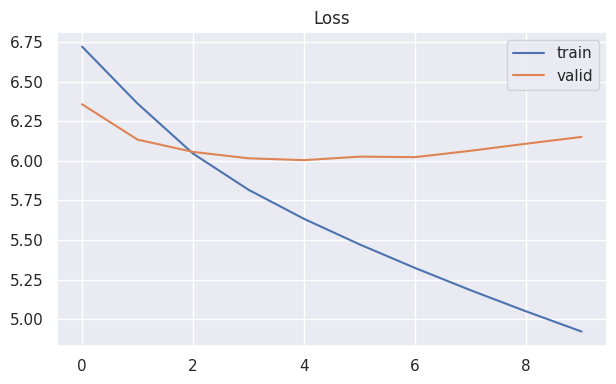

In [87]:
sns.set()
fig = plt.figure(0, (12, 4))

ax = plt.subplot(1, 2, 1)
sns.lineplot(history.history['loss'], label='train')
sns.lineplot(history.history['val_loss'], label='valid')
plt.title('Loss')
plt.tight_layout()

plt.show()

## Evaluating on the test set

Perplexity is the exponentiated cross-entropy loss, which puts it on the same scale as the KenLM figure from the n-gram notebook.


In [88]:
test_loss, test_accuracy = model.evaluate(test_Xy)

108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.0803 - loss: 6.2098


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [89]:
perplexity = np.exp(test_loss)

In [90]:
print(f"Test Loss: {test_loss}")
print(f"Perplexity: {perplexity}")

Test Loss: 6.209769248962402
Perplexity: 497.5864194559506


## Generating text

Sampling with a **temperature** parameter. Logits are divided by the temperature before the softmax: values below 1 sharpen the distribution toward the most likely token, values above 1 flatten it toward uniform.


In [92]:
def generate_text(model, tokenizer, seed_text, num_words=20, temperature=1):
    input_timesteps = 20  # Number of words to consider for the context
    text = seed_text

    num_tokens = len(tokenizer.word_index) + 1
    temperature = max(temperature, 1e-8)

    for _ in range(num_words):
        # Convert text to token sequence
        token_list = tokenizer.texts_to_sequences([text])[0]

        # Keep only the last input_timesteps tokens
        token_list = token_list[-input_timesteps:]

        # Pad the sequence to fixed length
        token_list = pad_sequences([token_list], maxlen=input_timesteps, padding='pre')

        # One-hot encode the input to match the model input shape
        x = tf.one_hot(tf.cast(token_list, tf.int32), depth=num_tokens)

        # Predict the probability distribution for the next word
        preds = model.predict(x, verbose=0)[0, -1]

        # Ignore the padding token
        preds[0] = 0

        # Apply temperature scaling
        preds = np.asarray(preds).astype("float64")
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Sample the next token
        next_token_id = np.random.choice(range(num_tokens), p=preds)
        next_word = tokenizer.index_word.get(next_token_id, "")

        if next_word == "":
            continue

        # Append the predicted word to the text
        text += " " + next_word

    return text

## Generation across temperatures

The same seed used in the KenLM notebook, so the two models can be compared directly: **"Romeo took a plane to visit his uncle"**.


**Temperature 0.01**


In [93]:

temperature= 0.01

In [94]:
generated_text = generate_text(model, tokenizer, "Romeo took a plane to visit his uncle", temperature = temperature)
print(generated_text)

Romeo took a plane to visit his uncle gloucester and i have been as i am a man as i am a man as i am a man


**Temperature 0.2**


In [95]:

temperature= 0.2

In [96]:
generated_text = generate_text(model, tokenizer, "Romeo took a plane to visit his uncle", temperature = temperature)
print(generated_text)

Romeo took a plane to visit his uncle gloucester and i have done to the king of york and then we are in the world of the world


**Temperature 0.5**


In [97]:

temperature= 0.5

In [98]:
generated_text = generate_text(model, tokenizer, "Romeo took a plane to visit his uncle", temperature = temperature)
print(generated_text)

Romeo took a plane to visit his uncle gloucester and i am not the lamb coriolanus thy lord of york when you will meet thee leave us to


**Temperature 0.7**


In [99]:

temperature= 0.7

In [106]:
generated_text = generate_text(model, tokenizer, "Romeo took a plane to visit his uncle", temperature = temperature)
print(generated_text)

Romeo took a plane to visit his uncle which we verona disturb'd hope assuage hard slaves left another's summers berkeley and hate lacks any more apparent in such


**Temperature 1.0**


In [101]:

temperature= 1

In [102]:
generated_text = generate_text(model, tokenizer, "Romeo took a plane to visit his uncle", temperature = temperature)
print(generated_text)

Romeo took a plane to visit his uncle each never to a mansion princess juliet persuades me a branch i'll give hundred blood voices brutus come aufidius steel


**Temperature 2.0**


In [103]:

temperature= 2

In [104]:
generated_text = generate_text(model, tokenizer, "Romeo took a plane to visit his uncle", temperature = temperature)
print(generated_text)

Romeo took a plane to visit his uncle should seem seeks fun hugh intelligencing bids shilling insurrections nice silly wolf will gratulate the basilisk side attention iron sinks


## Observations on temperature


From the generated examples, I observed that temperature has a very strong effect on the quality and style of the generated text. At very low temperatures such as 0.01 and 0.2, the model becomes highly conservative and repeatedly chooses the most likely next words, so the text is more stable but also much more repetitive and less creative. At medium temperatures such as 0.5 and 0.7, the generated sentences become more natural and interesting, because the model still keeps some coherence while allowing more variety in word selection. At higher temperatures such as 1 and especially 2, the output becomes increasingly random, with unusual word choices and weaker sentence structure, so creativity increases but overall coherence and grammatical quality decrease. Based on these results, the best balance in my experiment appears around the middle range, especially 0.5 to 0.7, where the text is neither too repetitive nor too chaotic.


## Comparing the statistical and neural approaches


Based on my experience in Part A and Part B, I concluded that both approaches are useful, but they serve different purposes and have different strengths. Part A, which uses a statistical KenLM language model, helped me understand the core idea of language modeling through n-gram probabilities, local context, and perplexity, but its generated text was generally more limited and more repetitive. In contrast, Part B used a Transformer-based causal language model, which was more powerful for text generation because it could produce more flexible and diverse continuations and could be controlled more effectively with temperature during sampling. I also noticed that the Transformer model gave better generation behavior overall, while the statistical model was simpler and easier for understanding the foundations. Therefore, my conclusion is that Part A is very useful for learning the basics of language modeling, but Part B is more suitable for producing richer and more realistic text.
